In [1]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf

print(tf.__version__)


I0000 00:00:1791275349.577439   40733 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791275349.577673   40733 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791275349.610775   40733 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791275350.492373   40733 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

2.21.0


In [3]:
# Feedforward Neural Network for MNIST Classification
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape :", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing data shape : (10000, 28, 28)
Testing labels shape: (10000,)


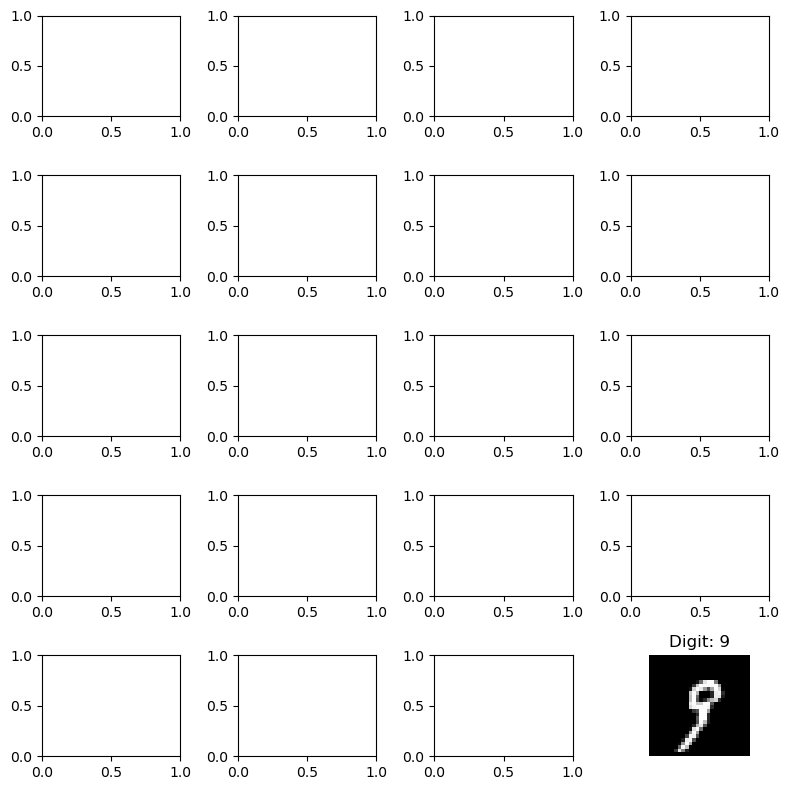

In [5]:
plt.figure(figsize=(8, 8))
for i in range(20):
    plt.subplot(5, 4, i + 1)
plt.imshow(x_train[i], cmap="gray")
plt.title("Digit: " + str(y_train[i]))
plt.axis("off")
plt.tight_layout()
plt.show()

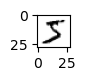

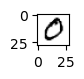

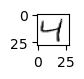

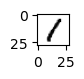

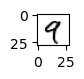

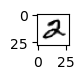

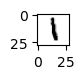

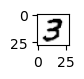

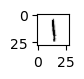

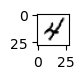

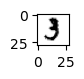

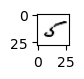

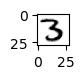

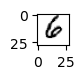

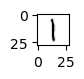

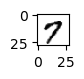

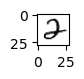

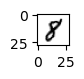

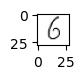

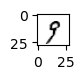

In [6]:
plt.figure(figsize=(5,5))
for k in range(20):
    plt.subplot(10,2,k+1)
    plt.imshow(x_train[k],cmap='Greys')
    plt.axis('on')
    plt.show()

In [7]:
# Convert each 28 x 28 image into a 784-element vector
x_train = x_train.reshape(x_train.shape[0], 784).astype("float32")
x_test = x_test.reshape(x_test.shape[0], 784).astype("float32")

In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0
print("After preprocessing:")
print("Training data shape:", x_train.shape)
print("Testing data shape :", x_test.shape)

After preprocessing:
Training data shape: (60000, 784)
Testing data shape : (10000, 784)


In [9]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPUs: []


E0000 00:00:1791275450.781672   40733 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model = Sequential([
Input(shape=(784,)),
# Hidden layer: 64 neurons
Dense(64, activation="sigmoid"),
# Output layer: 10 neurons for digits 0-9
Dense(10, activation="softmax")
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
optimizer=SGD(learning_rate=0.03),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)

In [13]:
history = model.fit(
x_train,y_train,
batch_size=128,
epochs=20,
validation_split=0.1,
verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6536 - loss: 1.6827 - val_accuracy: 0.8210 - val_loss: 1.1468
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8137 - loss: 0.9576 - val_accuracy: 0.8710 - val_loss: 0.7232
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8475 - loss: 0.6978 - val_accuracy: 0.8905 - val_loss: 0.5548
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.8644 - loss: 0.5781 - val_accuracy: 0.8993 - val_loss: 0.4673
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8751 - loss: 0.5095 - val_accuracy: 0.9035 - val_loss: 0.4144
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8816 - loss: 0.4648 - val_accuracy: 0.9088 - val_loss: 0.3797
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8873 - loss: 0.4334 - val_accuracy: 0.9137 - val_loss: 0.3544
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8909 - loss: 0.4100 - val_accuracy: 

In [14]:
test_loss, test_accuracy = model.evaluate(
x_test,
y_test,
verbose=0
)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.285513699054718
Test Accuracy: 0.9196000099182129


In [15]:
y_probability = model.predict(x_test, verbose=0)

In [17]:
y_pred = np.argmax(y_probability, axis=1)

In [18]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 960    0    2    2    0    4    8    1    3    0]
 [   0 1107    2    2    0    1    4    2   17    0]
 [  13    6  911   13   13    1   14   11   43    7]
 [   3    1   18  925    0   22    2   11   22    6]
 [   1    5    4    0  909    0   10    2   10   41]
 [   9    2    4   50    8  762   16    6   28    7]
 [  12    3    5    0   14   10  909    1    4    0]
 [   4   12   24    5    9    0    0  941    3   30]
 [   6    8    7   24    8   22   12   11  871    5]
 [  13    7    3   12   38    6    0   22    7  901]]


In [19]:
print("\nClassification Report:")
print(
classification_report(
y_test,
y_pred,
zero_division=0
)
)


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.88      0.91      1032
           3       0.90      0.92      0.91      1010
           4       0.91      0.93      0.92       982
           5       0.92      0.85      0.89       892
           6       0.93      0.95      0.94       958
           7       0.93      0.92      0.92      1028
           8       0.86      0.89      0.88       974
           9       0.90      0.89      0.90      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



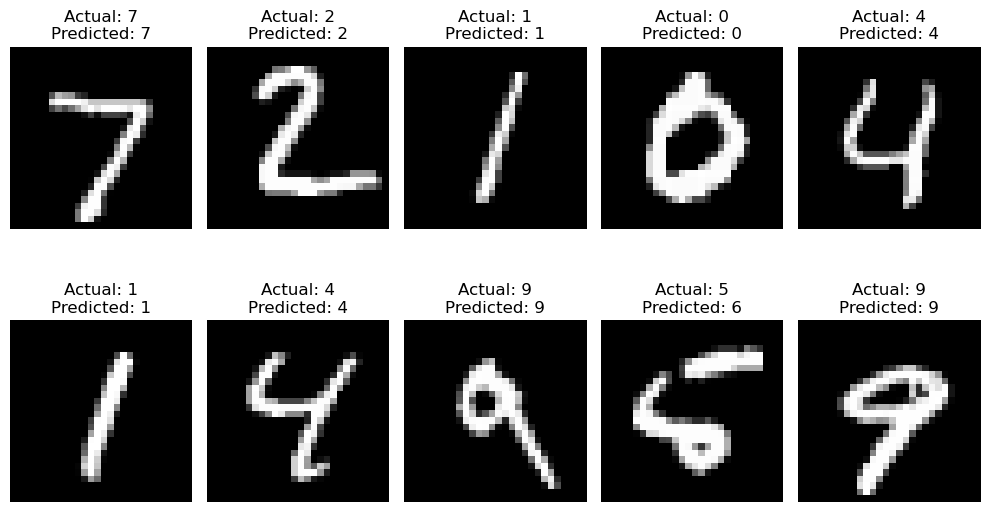

In [20]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # Reshape 784 values back to 28 x 28
    image = x_test[i].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.title(
    "Actual: " + str(y_test[i]) +
    "\nPredicted: " + str(y_pred[i])
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'epoch')

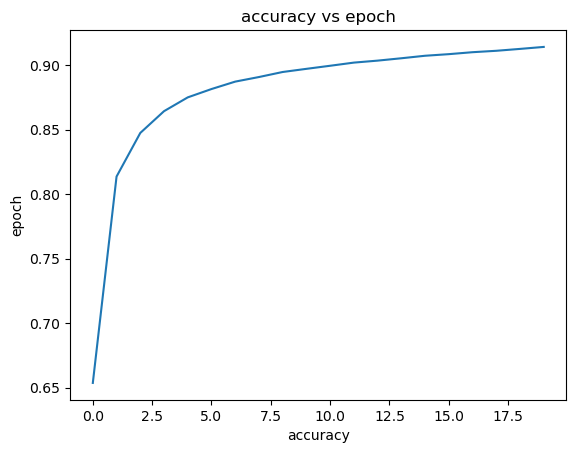

In [21]:
plt.plot(history.history['accuracy'])
plt.title('accuracy vs epoch')
plt.xlabel('accuracy')
plt.ylabel('epoch')

Text(0, 0.5, 'epoch')

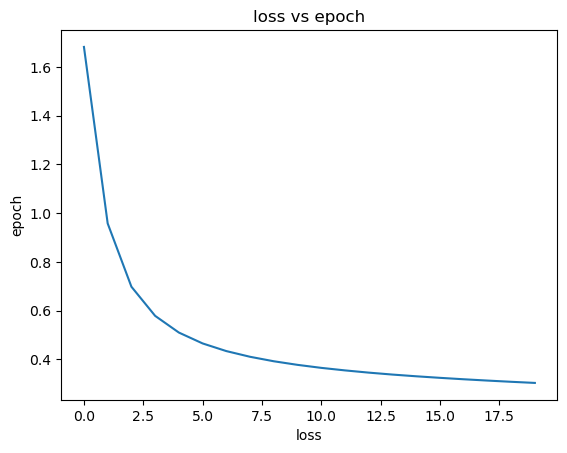

In [22]:
plt.plot(history.history['loss'])
plt.title('loss vs epoch')
plt.xlabel('loss')
plt.ylabel('epoch')


In [27]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
(xtrain,ytrain),(xtest,ytest) = datasets.cifar10.load_data()

In [28]:
xtrain.shape

(50000, 32, 32, 3)

In [29]:
xtest.shape

(10000, 32, 32, 3)

TypeError: Invalid shape (1,) for image data

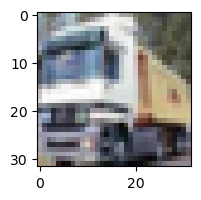

In [35]:
classes =['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
def plot_sample(x,y,index):
    plt.figure(figsize=(14,2))
    plt.imshow(x[index])
    plt.imshow(y[index])
plot_sample(xtrain,ytrain,1)

I0000 00:00:1791279357.835941   52625 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791279357.836989   52625 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791279358.091362   52625 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791279359.274151   52625 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

(50000, 32, 32, 3)
(10000, 32, 32, 3)


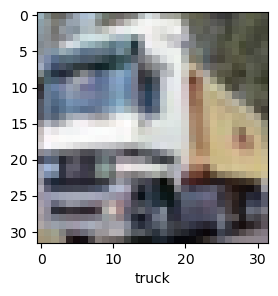

E0000 00:00:1791279362.384066   52625 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4598 - loss: 1.4912 - val_accuracy: 0.5358 - val_loss: 1.2852
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.5891 - loss: 1.1680 - val_accuracy: 0.6076 - val_loss: 1.1121
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6389 - loss: 1.0304 - val_accuracy: 0.6384 - val_loss: 1.0480
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6724 - loss: 0.9420 - val_accuracy: 0.6620 - val_loss: 0.9802
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6963 - loss: 0.8719 - val_accuracy: 0.6779 - val_loss: 0.9491
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7165 - loss: 0.8171 - val_accuracy: 0.6769 - val_loss: 0.9462
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7314 - loss: 0.7707 - val_accuracy: 0.6754 - val_loss: 0.9601
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7465 - loss: 0.7258 -

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report

# Load CIFAR-10 dataset
(xtrain, ytrain), (xtest, ytest) = datasets.cifar10.load_data()

print(xtrain.shape)
print(xtest.shape)

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Display sample image
def plot_sample(x, y, index):
    plt.figure(figsize=(3, 3))
    plt.imshow(x[index])
    plt.xlabel(classes[y[index][0]])
    plt.show()

plot_sample(xtrain, ytrain, 1)

# Normalize
xtrain = xtrain.astype('float32') / 255.0
xtest = xtest.astype('float32') / 255.0

# CNN model
cnn = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # Feature extraction
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Classification
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = cnn.fit(
    xtrain,
    ytrain,
    epochs=20,
    validation_data=(xtest, ytest)
)

# Evaluate
test_loss, test_accuracy = cnn.evaluate(xtest, ytest)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Prediction
ypred = cnn.predict(xtest)

yclasses = [np.argmax(element) for element in ypred]

# Classification report
ytest_flat = ytest.reshape(-1)

print("Classification Report:")
print(
    classification_report(
        ytest_flat,
        yclasses,
        target_names=classes
    )
)
